✅ Saved scatterplot to /home/pbellec/git/airoh-mini/output_data/figures/figure_simulation/scatter.png
✅ Saved histogram to /home/pbellec/git/airoh-mini/output_data/figures/figure_simulation/histogram.png


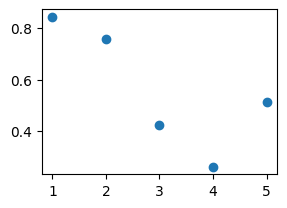

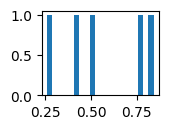

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from airoh.figures import panel_size

# Panels are placed in the montage at 1:1, so save at the page DPI and never
# pass bbox_inches="tight" — tight cropping resizes the canvas after the
# fact, breaking the 1:1 guarantee. Use layout="constrained" instead to
# reclaim margins inside the fixed canvas.
#
# The DPI comes from `figures:` in invoke.yaml, exported by `run-notebooks`:
# saved pixels must equal figsize × dpi, so hardcoding it here would silently
# break placement the moment the montage was composed at another resolution.
FIGURE_DPI = int(os.environ.get("FIGURE_MONTAGE_DPI", 300))

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()
figures_base = Path(os.environ.get("FIGURES_DIR", output_dir / "figures")).resolve()

# Each notebook writes into its own folder, named after the notebook, under
# the shared figures tree. That folder is also what `run-notebooks` treats as
# the "already ran" marker: if it exists, the notebook is skipped. Writing
# somewhere else means the notebook re-runs on every `invoke run`.
figure_dir = figures_base / "figure_simulation"
figure_dir.mkdir(parents=True, exist_ok=True)


def panel(name, default):
    """Size in inches for the panel placed as `name` in figure_montage.svg.

    A panel the montage does not (yet) place keeps `default`, so this
    notebook still runs standalone before `invoke run-figure-layout` has ever
    produced panel_sizes.json.
    """
    return panel_size(f"figure_simulation/{name}", default)


df = pd.read_csv(output_dir / "simulation_output.csv")

plt.figure(figsize=panel("scatter.png", default=(4, 3)), layout="constrained")
plt.scatter(df["id"], df["value"])
plt.savefig(figure_dir / "scatter.png", dpi=FIGURE_DPI)
print(f"✅ Saved scatterplot to {figure_dir}/scatter.png")

plt.figure(figsize=panel("histogram.png", default=(4, 3)), layout="constrained")
plt.hist(df["value"], bins=20)
plt.savefig(figure_dir / "histogram.png", dpi=FIGURE_DPI)
print(f"✅ Saved histogram to {figure_dir}/histogram.png")